<a href="https://colab.research.google.com/github/0xs1d/pwskills/blob/main/Assignment_DS_AG_019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 1
**What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.**

Deep Learning is a sub-field of machine learning that uses artificial neural networks with multiple layers to learn hierarchical feature representations. Unlike traditional ML, which requires manual feature engineering, deep learning extracts features automatically.

**Evolution:**
- 1950s–1980s: Early neural networks (Perceptron, Backpropagation)
- 1990s: SVMs and other ML methods dominated
- 2000s–2010s: GPU growth, big datasets revived deep learning
- 2012–present: State‑of‑the‑art in vision, NLP, speech

**Difference from traditional ML:**
- Learns from raw data vs. manual features  
- Requires large datasets  
- Uses deep neural architectures  


## Question 2
**Explain the basic architecture and functioning of a Perceptron. What are its limitations?**

A perceptron consists of:
- Inputs  
- Weights  
- Bias  
- Activation function (step)

It computes:  **y = f(w·x + b)**.

**Limitations:**
- Only solves linearly separable problems  
- Cannot solve XOR  
- No differentiability with step function  


## Question 3
**Purpose of activation functions + Comparison of Sigmoid, ReLU, Tanh.**

Activation functions provide non-linearity.

| Function | Pros | Cons |
|---------|------|------|
| Sigmoid | Smooth, 0–1 output | Vanishing gradient |
| ReLU | Fast, efficient | Dead neurons |
| Tanh | Zero-centered | Still vanishing gradients |


## Question 4
**Loss vs Cost function**

- **Loss function:** Error for a single sample  
- **Cost function:** Average loss over dataset  

Examples:
- Loss: MSE, Binary Cross Entropy  
- Cost: Mean of BCE across all samples  


## Question 5
**Role of optimizers + comparison**

Optimizers update weights to minimize loss.

| Optimizer | Pros | Cons |
|----------|------|------|
| Gradient Descent | Simple | Slow |
| RMSprop | Adaptive | Needs tuning |
| Adam | Fast, adaptive | More memory |


## Question 6
**Single-layer perceptron for AND gate (NumPy)**

In [1]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

weights = np.zeros(2)
bias = 0
lr = 0.1

def step(x):
    return 1 if x > 0 else 0

for epoch in range(20):
    for i in range(len(X)):
        linear = np.dot(X[i], weights) + bias
        pred = step(linear)
        error = y[i] - pred
        weights += lr * error * X[i]
        bias += lr * error

print("Weights:", weights)
print("Bias:", bias)

for i in range(len(X)):
    print(X[i], "→", step(np.dot(X[i], weights) + bias))

Weights: [0.2 0.1]
Bias: -0.2
[0 0] → 0
[0 1] → 0
[1 0] → 0
[1 1] → 1


## Question 7
**Visualize Sigmoid, ReLU, Tanh (Matplotlib)**

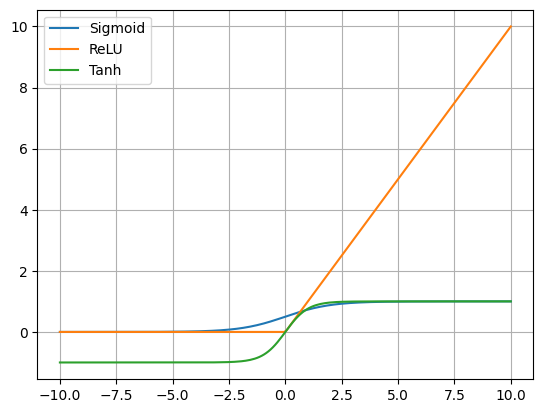

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10,10,200)
sigmoid = 1/(1+np.exp(-x))
relu = np.maximum(0,x)
tanh = np.tanh(x)

plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, relu, label="ReLU")
plt.plot(x, tanh, label="Tanh")
plt.legend()
plt.grid()
plt.show()

## Question 8
**Keras MNIST classifier**

In [3]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train/255.0
x_test = x_test/255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, batch_size=32)

history.history['accuracy'][-1]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8814 - loss: 0.4265
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9640 - loss: 0.1209
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9764 - loss: 0.0783
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9836 - loss: 0.0544
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9870 - loss: 0.0430


0.9861000180244446

## Question 9
**Train on Fashion-MNIST & plot curves**

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7597 - loss: 0.9040 - val_accuracy: 0.8477 - val_loss: 0.4240
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8587 - loss: 0.3965 - val_accuracy: 0.8686 - val_loss: 0.3712
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8694 - loss: 0.3514 - val_accuracy: 0.8718 - val_loss: 0.3595
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8851 - loss: 0.3249 - val_accuracy: 0.8808 - val_loss: 0.3411
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8873 - loss: 0.3037 - val_accuracy: 0.8716 - val_loss: 0.3684


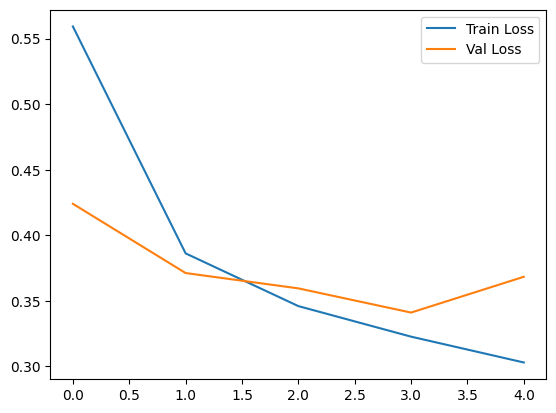

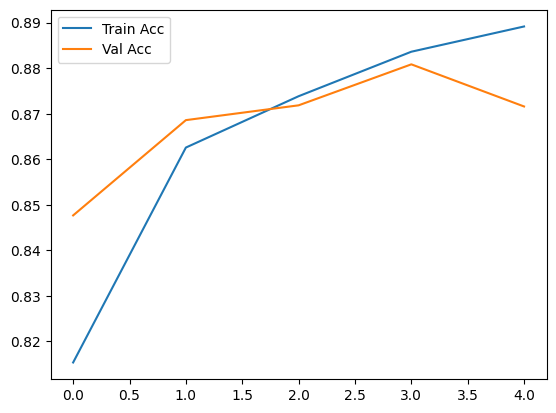

In [4]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train/255.0
x_test = x_test/255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

## Question 10
**Fraud Detection Deep Learning Workflow**
Includes design, activation, handling imbalance, optimizer, and overfitting prevention.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

num_features = 30  # placeholder

model = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(0.001),
              loss='binary_crossentropy',
              metrics=['accuracy','AUC'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
